# Sigma1 Experiment Count Convergence

How many compact sequences are needed for stable sigma1 fits?

This notebook fixes sigma0 from Stage A, generates a large pool of
high-diversity compact sequences, then runs `fit_sigma_1d` for sigma1
with increasing numbers of randomly-sampled sequences. All fits use
the **sparse 12-point AUROC** method (`compute_auroc_sparse12`).

The goal: identify the minimum number of sequences where best-fit
sigma1 stabilizes and the MSE landscape is well-resolved.

| Sweep parameter | Values |
|-----------------|--------|
| `N_SEQS` | 3, 5, 8, 10, 15, 20, 30 |
| `n_seqs_per_rep` | N (all sequences used each MC rep) |
| `N_MC` | 8 |
| `N_GRID` | 10 |
| AUROC method | sparse 12-point |

In [1]:
import sys, os, yaml, torch
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from collections import Counter
from scipy.spatial.distance import pdist

sys.path.append('/orcd/data/jhm/001/om2/jmhicks/projects/TextureStreaming/code/')
sys.path.append('/orcd/data/jhm/001/om2/bjmedina/auditory-memory/memory/utls/')
sys.path.append('/orcd/data/jhm/001/om2/bjmedina/auditory-memory/memory/src/model/')
sys.path.append('/orcd/data/jhm/001/om2/bjmedina/auditory-memory/memory/')

from chexture_choolbox.auditorytexture.texture_model import TextureModel
from chexture_choolbox.auditorytexture.helpers import FlattenStats
from texture_prior.params import model_params, statistics_set, texture_dataset
from texture_prior.utils import path

from utls.plotting import ensure_dir
from utls.loading import (
    load_results_with_exclusion_2,
    move_sequences_to_used,
    load_results_with_exclusion_no_dropping,
)
from utls.runners_v2 import run_experiment_scores, make_noise_schedule
from utls.runners_utils import *
from utls.analysis_helpers import auroc_to_dprime
from utls.io_utils import (
    make_model_save_dir,
    save_all_figures,
    save_single_figure,
    save_runs_summary,
)
from encoders import *

from utls.toy_experiments import (
    make_toy_experiment_list,
    make_compact_multi_isi_sequences,
    infer_trial_isis,
    make_high_diversity_sequences
)
from utls.sigma_fitting import (
    log_mid,
    fit_sigma_1d,
    plot_sigma_fit,
    compute_auroc_sparse12,
)

## 1. Load config & data

In [2]:
def load_config(cfg_path):
    cfg_path = Path(cfg_path)
    if not cfg_path.exists():
        raise FileNotFoundError(cfg_path)
    with open(cfg_path) as f:
        return yaml.safe_load(f), cfg_path


CONFIG_PATH = (
    "/orcd/data/jhm/001/om2/bjmedina/auditory-memory/memory/"
    "model_yamls/three-regime/resnet50/nontime_avg/run_000005.yaml"
)

model_cfg, model_cfg_path = load_config(CONFIG_PATH)
print(model_cfg)

{'results_root': '/orcd/data/jhm/001/om2/bjmedina/auditory-memory/memory', 'tag': 'slurm', 'experiment': {'is_multi': True, 'n_seqs': 36, 'n_samples': 50, 'which_task': 0}, 'metric': 'cosine', 'noise_model': {'name': 'three-regime', 'sigma0_min': 3.0, 'sigma0_max': 0.5, 'sigma1_min': 0.1, 'sigma1_max': 0.6, 'sigma2_min': 0.0005, 'sigma2_max': 0.1, 't_step': 5}, 'run_id': 'run_000005', 'representation': {'type': 'resnet50', 'layer': 'layer4', 'time_avg': False}}


In [3]:


# ---- experiment ----
exp_cfg = model_cfg["experiment"]
which_task = exp_cfg["which_task"]
is_multi = exp_cfg["is_multi"]
which_isi = exp_cfg.get("which_isi", None)

isis = [0, 1, 2, 4, 8, 16, 32, 64] if is_multi else [0, which_isi]

# ---- metric ----
metric = model_cfg["metric"]

# ---- noise model ----
noise_cfg = model_cfg["noise_model"]
noise_mode = noise_cfg["name"]
t_step = noise_cfg["t_step"]

# ---- representation ----
repr_cfg = model_cfg["representation"]
time_avg = repr_cfg["time_avg"]
encoder_type = repr_cfg["type"]
layer = repr_cfg.get("layer", None)
pc_dims = repr_cfg.get("pc_dims", None)

# ---- load human data ----
exp_list, all_files, name_to_idx, human_runs, task_name, hr_task_name = (
    load_experiment_data(which_task, which_isi, is_multi, old=False)
)

human_curve = compute_human_curve(human_runs, is_multi, which_isi)
print("ISIs:", isis)
print("Human d' curve:", human_curve)
print(f"Total real sequences: {len(exp_list)}")

/orcd/data/jhm/001/om2/bjmedina/auditory-memory/memory/utls/runners_utils.py:210: RuntimeWarning: Mean of empty slice
  dprimes.append(np.nanmean(aucs))


ISIs: [0, 1, 2, 4, 8, 16, 32, 64]
Human d' curve: [3.43598043 2.97990883 2.44045657 2.13572119 2.01516641 1.89242487
 1.80438774 1.57475358]
Total real sequences: 104


## 2. Build encoder & encode stimuli

In [4]:
NN_ENCODERS = {"kell2018", "resnet50"}
encoder_task = (
    "word_speaker_audioset" if encoder_type in NN_ENCODERS else "audioset"
)

encoder_cfg = dict(
    encoder_type=encoder_type,
    model_name=encoder_type,
    task=encoder_task,
    statistics_dict=statistics_set.statistics,
    model_params=model_params,
    pc_dims=pc_dims,
    sr=20000,
    duration=2.0,
    rms_level=0.05,
    time_avg=time_avg,
    device="cuda",
)

if encoder_type in NN_ENCODERS:
    encoder_cfg["layer"] = layer
if encoder_type == "texture":
    encoder_cfg["pc_dims"] = pc_dims

encoder_name = make_encoder_name(encoder_cfg)
print("Encoder name:", encoder_name)

encoder = build_encoder(encoder_cfg)
X = encode_stimuli(encoder, all_files)
X_np = X.detach().cpu().numpy()
print("Encoded shape:", X_np.shape, "  any NaN?", torch.isnan(X).any().item())

Encoder name: resnet50-layer4
LOADING FROM /orcd/data/jhm/001/om2/bjmedina/models/cochdnn/model_directories/resnet50_word_speaker_audioset/
=> loading checkpoint '/orcd/data/jhm/001/om2/bjmedina/models/cochdnn/model_checkpoints/audio_rep_training_cochleagram_1/standard_training_word_and_audioset_and_speaker_decay_lr/542752d7-9849-49ff-b84a-6758a81585b4/5_checkpoint.pt'
=> loaded checkpoint '/orcd/data/jhm/001/om2/bjmedina/models/cochdnn/model_checkpoints/audio_rep_training_cochleagram_1/standard_training_word_and_audioset_and_speaker_decay_lr/542752d7-9849-49ff-b84a-6758a81585b4/5_checkpoint.pt' (epoch 6)
Encoded shape: (80, 186368)   any NaN? False


## 3. Parameter bounds & stimulus pool

In [12]:
def median_pairwise_distance(X, metric="euclidean", n_samples=500, seed=0):
    rng = np.random.default_rng(seed)
    idx = rng.choice(X.shape[0], size=min(n_samples, X.shape[0]), replace=False)
    return float(np.median(pdist(X[idx], metric=metric)))


d50 = 1#median_pairwise_distance(X_np, metric="cosine")
print(f"Median pairwise cosine distance: {d50:.6f}")

param_bounds = {
    "sigma0": (
        0.01,
        22,
    ),
    "sigma1": (
        1.0,
        12,
    ),
    "sigma2": (
        0.0001,
        5,
    ),
}

print("Parameter bounds:")
for k, v in param_bounds.items():
    print(f"  {k}: ({v[0]:.6f}, {v[1]:.6f})")

# Stimulus pool for sequence generation
stimulus_pool = sorted({s for seq in exp_list for s in seq})
print(f"\nStimulus pool size: {len(stimulus_pool)}")
assert len(stimulus_pool) >= 65, (
    f"Stimulus pool ({len(stimulus_pool)}) too small for ISI-64 blocks (need >= 65)"
)

Median pairwise cosine distance: 1.000000
Parameter bounds:
  sigma0: (0.010000, 22.000000)
  sigma1: (1.000000, 12.000000)
  sigma2: (0.000100, 5.000000)

Stimulus pool size: 80


## 4. Human d' targets

In [13]:
isi_to_hc_idx = {isi_val: i for i, isi_val in enumerate(isis)}

sigma0_human = {0: float(human_curve[isi_to_hc_idx[0]])}
sigma1_human = {isi: float(human_curve[isi_to_hc_idx[isi]]) for isi in [1, 2, 4]}
sigma2_human = {isi: float(human_curve[isi_to_hc_idx[isi]]) for isi in [8, 16, 32, 64]}

print("Stage A targets (sigma0):")
for isi, dp in sigma0_human.items():
    print(f"  ISI {isi}: human d' = {dp:.4f}")

print("\nStage B targets (sigma1):")
for isi, dp in sigma1_human.items():
    print(f"  ISI {isi}: human d' = {dp:.4f}")

print("\nStage C targets (sigma2):")
for isi, dp in sigma2_human.items():
    print(f"  ISI {isi}: human d' = {dp:.4f}")

# Initial values for unfitted sigmas
sigma1_init = log_mid(*param_bounds["sigma1"])
sigma2_init = log_mid(*param_bounds["sigma2"])
print(f"\nInitial sigma1 = {sigma1_init:.6f}")
print(f"Initial sigma2 = {sigma2_init:.6f}")

Stage A targets (sigma0):
  ISI 0: human d' = 3.4360

Stage B targets (sigma1):
  ISI 1: human d' = 2.9799
  ISI 2: human d' = 2.4405
  ISI 4: human d' = 2.1357

Stage C targets (sigma2):
  ISI 8: human d' = 2.0152
  ISI 16: human d' = 1.8924
  ISI 32: human d' = 1.8044
  ISI 64: human d' = 1.5748

Initial sigma1 = 3.464102
Initial sigma2 = 0.022361


---
## Stage A: Fit sigma0 (ISI = 0, toy experiments)

ISI=0 means immediate repeats — only one step of noise, so only sigma0
matters.  Standard toy experiments (pairs of identical stimuli) are
efficient here.

In [14]:
isi0_exps = {
    0: make_toy_experiment_list(
        stimulus_pool, isi=0, n_experiments=100, k_stimuli=5, seed=0
    )
}
print(f"ISI-0 toy experiments: {len(isi0_exps[0])} exps, "
      f"avg len {np.mean([len(e) for e in isi0_exps[0]]):.0f} trials")

N_REFINE_ITERS = 2
N_MC = 8

stage_a = fit_sigma_1d(
    run_experiment_fn=run_experiment_scores,
    sigma_name="sigma0",
    sigma_bounds=param_bounds["sigma0"],
    fixed_sigmas={"sigma1": sigma1_init, "sigma2": sigma2_init},
    noise_mode=noise_mode,
    metric=metric,
    X0=X,
    name_to_idx=name_to_idx,
    experiments_by_isi=isi0_exps,
    human_dprimes_by_isi=sigma0_human,
    t_step=t_step,
    n_grid=15,
    n_mc=N_MC,
    n_refine_iters=N_REFINE_ITERS,
    seed=0,
    auroc_fn=compute_auroc_sparse12,
)

sigma0_fitted = stage_a["best_sigma"]
print(f"\n>>> sigma0 = {sigma0_fitted:.6f}  (MSE = {stage_a['best_mse']:.6f})")
plot_sigma_fit(stage_a, human_dprimes_by_isi=sigma0_human,
               title="Stage A: sigma0 (ISI = 0)");

ISI-0 toy experiments: 100 exps, avg len 10 trials

--- sigma0 iteration 1/2 ---
  Bounds: (0.010000, 22.000000), 15 candidates


Fitting sigma0 (iter 1):   0%|          | 0/15 [00:00<?, ?it/s]

evaluate_sigma_on_multi_isi_sequences_sample


KeyboardInterrupt: 

In [ ]:
all_stimuli = set()

for i in range(len(isi0_exps[0])):
    all_stimuli = all_stimuli.union(set(isi0_exps[0][i]))

print(len(all_stimuli))

---
## Stage B: Sigma1 experiment count convergence

Generate a large pool of sequences, then sweep over how many are used
for the sigma1 fit.

In [15]:
SIGMA1_ISIS = [1, 2, 4]
SIGMA1_LENGTH = 60
SIGMA1_MIN_PAIRS = 5
POOL_SIZE = 30  # large pool to sample from

sigma1_all_exps, sigma1_all_isi_keys = make_high_diversity_sequences(
    stimulus_pool=stimulus_pool,
    isi_values=SIGMA1_ISIS,
    n_sequences=POOL_SIZE,
    length=SIGMA1_LENGTH,
    min_pairs_per_isi=SIGMA1_MIN_PAIRS,
    seed=1000,
)

print(f"Generated {len(sigma1_all_exps)} sequences, {len(sigma1_all_exps[0])} trials each")

# Validate ISI distribution
from collections import defaultdict
isi_counts = defaultdict(list)
for seq in sigma1_all_exps:
    counts = Counter(infer_trial_isis(seq))
    for isi_val in SIGMA1_ISIS:
        isi_counts[isi_val].append(counts.get(isi_val, 0))

print("\nPairs per ISI per sequence (mean +/- std):")
for isi_val in SIGMA1_ISIS:
    vals = isi_counts[isi_val]
    print(f"  ISI {isi_val}: {np.mean(vals):.1f} +/- {np.std(vals):.1f}  "
          f"(min={min(vals)}, max={max(vals)})")

Aggregate ISI usage across all sequences:
  ISI -1: 600
  ISI 1: 412
  ISI 2: 352
  ISI 4: 436
Generated 30 sequences, 60 trials each

Pairs per ISI per sequence (mean +/- std):
  ISI 1: 6.9 +/- 2.0  (min=5, max=10)
  ISI 2: 5.9 +/- 0.8  (min=5, max=8)
  ISI 4: 7.3 +/- 2.0  (min=5, max=10)


In [17]:
N_SEQS_SWEEP = [5, 10, 20, 30]
N_MC = 4
N_REFINE_ITERS = 2
N_GRID = 7

print(f"Sweep: {len(N_SEQS_SWEEP)} experiment counts")
print(f"N_SEQS values: {N_SEQS_SWEEP}")
print(f"N_MC={N_MC}, N_GRID={N_GRID}, N_REFINE_ITERS={N_REFINE_ITERS}")
print(f"AUROC method: compute_auroc_sparse12")

Sweep: 4 experiment counts
N_SEQS values: [5, 10, 20, 30]
N_MC=4, N_GRID=7, N_REFINE_ITERS=2
AUROC method: compute_auroc_sparse12


In [18]:
fit_by_n_seqs = {}

for N in N_SEQS_SWEEP:
    print(f"\n{'='*60}")
    print(f"  N_SEQS = {N}  (n_seqs_per_rep = {N})")
    print(f"{'='*60}")

    # Randomly sample N sequences from the pool
    rng = np.random.default_rng(seed=42 + N)
    indices = rng.choice(len(sigma1_all_exps), size=N, replace=False)
    exps_subset = [sigma1_all_exps[i] for i in indices]
    isi_keys_subset = [sigma1_all_isi_keys[i] for i in indices]

    result = fit_sigma_1d(
        run_experiment_fn=run_experiment_scores,
        sigma_name="sigma1",
        sigma_bounds=param_bounds["sigma1"],
        fixed_sigmas={"sigma0": 10, "sigma2": sigma2_init},
        noise_mode=noise_mode,
        metric=metric,
        X0=X,
        name_to_idx=name_to_idx,
        human_dprimes_by_isi=sigma1_human,
        t_step=t_step,
        n_grid=N_GRID,
        n_mc=N_MC,
        n_refine_iters=N_REFINE_ITERS,
        seed=100_000 + N,
        experiment_list=exps_subset,
        isi_keys=isi_keys_subset,
        target_isis=SIGMA1_ISIS,
        n_seqs_per_rep=N,
        auroc_fn=compute_auroc_sparse12,
    )

    fit_by_n_seqs[N] = result
    print(f"  >>> best sigma1 = {result['best_sigma']:.6f}  (MSE = {result['best_mse']:.6f})")

print("\nAll sweeps complete.")


  N_SEQS = 5  (n_seqs_per_rep = 5)

--- sigma1 iteration 1/2 ---
  Bounds: (1.000000, 12.000000), 7 candidates


Fitting sigma1 (iter 1):   0%|          | 0/7 [00:00<?, ?it/s]

evaluate_sigma_on_multi_isi_sequences_sample
evaluate_sigma_on_multi_isi_sequences_sample
evaluate_sigma_on_multi_isi_sequences_sample
evaluate_sigma_on_multi_isi_sequences_sample
evaluate_sigma_on_multi_isi_sequences_sample
evaluate_sigma_on_multi_isi_sequences_sample
evaluate_sigma_on_multi_isi_sequences_sample
  Best sigma1: 2.289428 (MSE: 0.036949)

--- sigma1 iteration 2/2 ---
  Bounds: (1.000000, 5.241483), 7 candidates


Fitting sigma1 (iter 2):   0%|          | 0/7 [00:00<?, ?it/s]

evaluate_sigma_on_multi_isi_sequences_sample
evaluate_sigma_on_multi_isi_sequences_sample
evaluate_sigma_on_multi_isi_sequences_sample
evaluate_sigma_on_multi_isi_sequences_sample
evaluate_sigma_on_multi_isi_sequences_sample
evaluate_sigma_on_multi_isi_sequences_sample
evaluate_sigma_on_multi_isi_sequences_sample
  Best sigma1: 1.706914 (MSE: 0.051554)
  >>> best sigma1 = 2.289428  (MSE = 0.036949)

  N_SEQS = 10  (n_seqs_per_rep = 10)

--- sigma1 iteration 1/2 ---
  Bounds: (1.000000, 12.000000), 7 candidates


...

evaluate_sigma_on_multi_isi_sequences_sample
evaluate_sigma_on_multi_isi_sequences_sample
evaluate_sigma_on_multi_isi_sequences_sample
evaluate_sigma_on_multi_isi_sequences_sample
evaluate_sigma_on_multi_isi_sequences_sample
evaluate_sigma_on_multi_isi_sequences_sample
evaluate_sigma_on_multi_isi_sequences_sample
  Best sigma1: 2.413828 (MSE: 0.035878)
  >>> best sigma1 = 2.289428  (MSE = 0.020819)

  N_SEQS = 30  (n_seqs_per_rep = 30)

--- sigma1 iteration 1/2 ---
  Bounds: (1.000000, 12.000000), 7 candidates


Fitting sigma1 (iter 1):   0%|          | 0/7 [00:00<?, ?it/s]

evaluate_sigma_on_multi_isi_sequences_sample
evaluate_sigma_on_multi_isi_sequences_sample
evaluate_sigma_on_multi_isi_sequences_sample
evaluate_sigma_on_multi_isi_sequences_sample
evaluate_sigma_on_multi_isi_sequences_sample
evaluate_sigma_on_multi_isi_sequences_sample
evaluate_sigma_on_multi_isi_sequences_sample
  Best sigma1: 2.289428 (MSE: 0.017182)

--- sigma1 iteration 2/2 ---
  Bounds: (1.000000, 5.241483), 7 candidates


Fitting sigma1 (iter 2):   0%|          | 0/7 [00:00<?, ?it/s]

evaluate_sigma_on_multi_isi_sequences_sample
evaluate_sigma_on_multi_isi_sequences_sample
evaluate_sigma_on_multi_isi_sequences_sample
evaluate_sigma_on_multi_isi_sequences_sample
evaluate_sigma_on_multi_isi_sequences_sample
evaluate_sigma_on_multi_isi_sequences_sample
evaluate_sigma_on_multi_isi_sequences_sample
  Best sigma1: 1.706914 (MSE: 0.029679)
  >>> best sigma1 = 2.289428  (MSE = 0.017182)

All sweeps complete.


---
## Convergence Plots

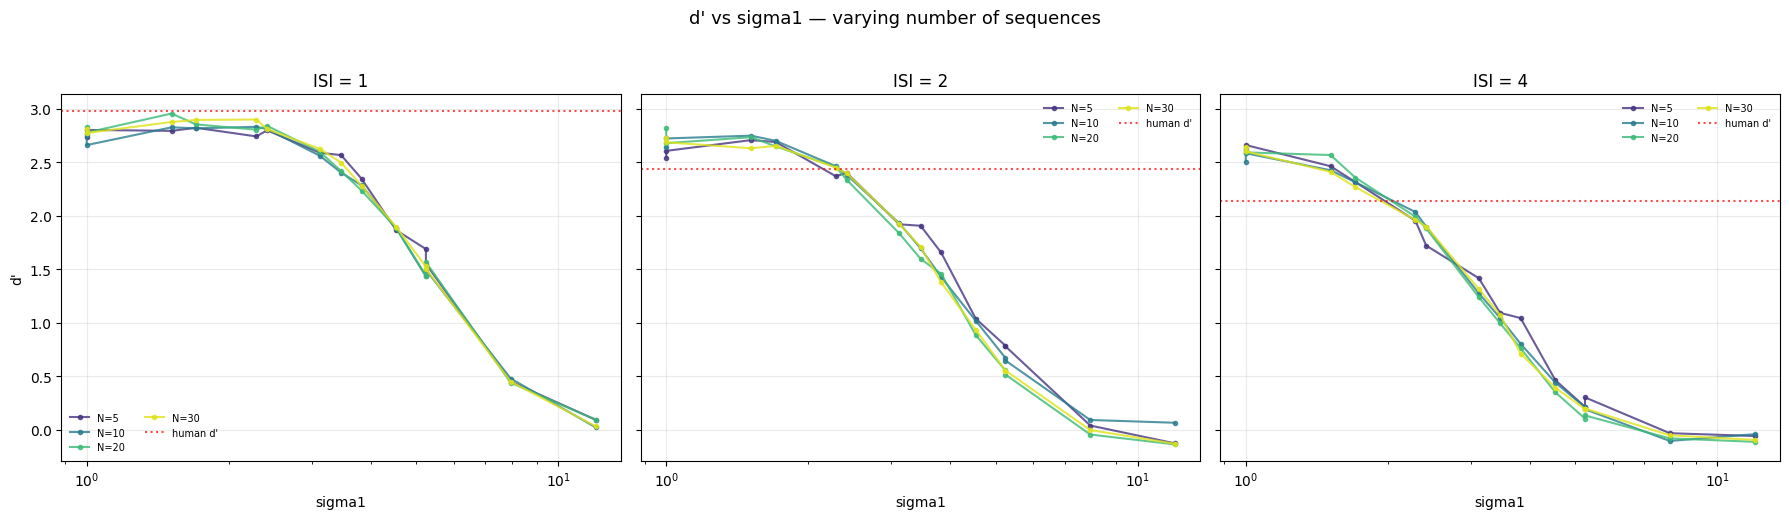

In [19]:
import matplotlib.cm as cm

fig, axes = plt.subplots(1, len(SIGMA1_ISIS), figsize=(6 * len(SIGMA1_ISIS), 5),
                         sharey=True)

colors = cm.viridis(np.linspace(0.15, 0.95, len(N_SEQS_SWEEP)))

for ax, isi_val in zip(axes, SIGMA1_ISIS):
    for color, N in zip(colors, N_SEQS_SWEEP):
        results = fit_by_n_seqs[N]["all_results"]
        sigma_vals = np.array([r["sigma_value"] for r in results])
        dp_key = "dprime_mean_by_isi" if "dprime_mean_by_isi" in results[0] else "dprime_by_isi"
        dp_vals = np.array([r[dp_key].get(isi_val, np.nan) for r in results])

        order = np.argsort(sigma_vals)
        ax.plot(sigma_vals[order], dp_vals[order], "o-", ms=3, color=color,
                label=f"N={N}", alpha=0.8)

    ax.axhline(sigma1_human[isi_val], ls=":", color="red", alpha=0.7, label="human d'")
    ax.set_xscale("log")
    ax.set_xlabel("sigma1")
    ax.set_title(f"ISI = {isi_val}")
    ax.grid(alpha=0.25)
    ax.legend(fontsize=7, frameon=False, ncol=2)

axes[0].set_ylabel("d'")
fig.suptitle("d' vs sigma1 — varying number of sequences", y=1.03, fontsize=13)
fig.tight_layout()
plt.show()

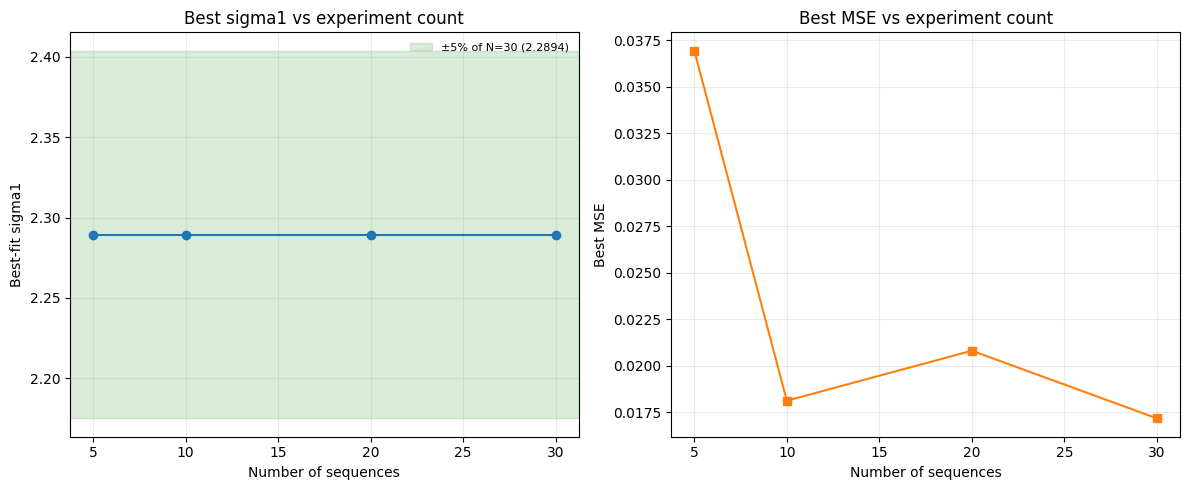

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

n_vals = np.array(N_SEQS_SWEEP)
best_sigmas = np.array([fit_by_n_seqs[N]["best_sigma"] for N in N_SEQS_SWEEP])
best_mses = np.array([fit_by_n_seqs[N]["best_mse"] for N in N_SEQS_SWEEP])

# Left: best sigma1 vs N
ax = axes[0]
ax.plot(n_vals, best_sigmas, "o-", ms=6, color="tab:blue")
ax.set_xlabel("Number of sequences")
ax.set_ylabel("Best-fit sigma1")
ax.set_title("Best sigma1 vs experiment count")
ax.grid(alpha=0.25)

# Reference band: +/- 5% of the N=30 value
ref = best_sigmas[-1]
ax.axhspan(ref * 0.95, ref * 1.05, alpha=0.15, color="green", label=f"\u00b15% of N=30 ({ref:.4f})")
ax.legend(frameon=False, fontsize=8)

# Right: best MSE vs N
ax = axes[1]
ax.plot(n_vals, best_mses, "s-", ms=6, color="tab:orange")
ax.set_xlabel("Number of sequences")
ax.set_ylabel("Best MSE")
ax.set_title("Best MSE vs experiment count")
ax.grid(alpha=0.25)

fig.tight_layout()
plt.show()

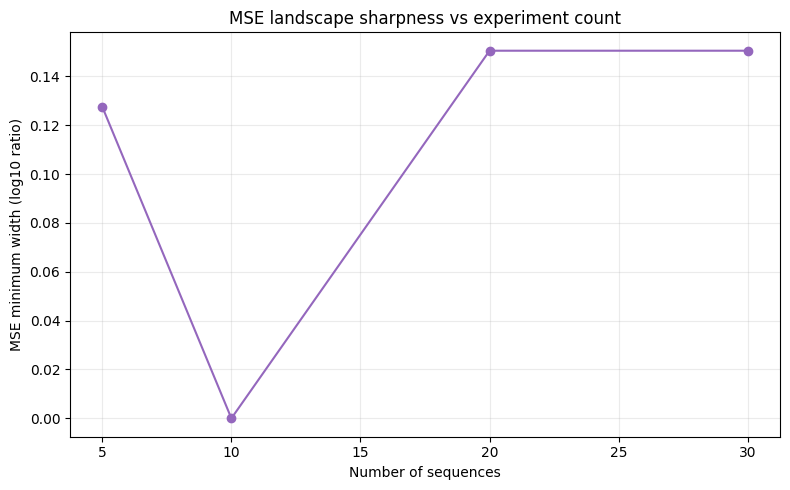

In [21]:
fig, ax = plt.subplots(figsize=(8, 5))

widths = []
for N in N_SEQS_SWEEP:
    results = fit_by_n_seqs[N]["all_results"]
    sigma_vals = np.array([r["sigma_value"] for r in results])
    mse_vals = np.array([r["mse_mean"] for r in results])

    best_mse = np.nanmin(mse_vals)
    threshold = 2 * best_mse
    within = sigma_vals[mse_vals <= threshold]
    width = np.log10(within.max() / within.min()) if len(within) > 1 else 0
    widths.append(width)

ax.plot(N_SEQS_SWEEP, widths, "o-", ms=6, color="tab:purple")
ax.set_xlabel("Number of sequences")
ax.set_ylabel("MSE minimum width (log10 ratio)")
ax.set_title("MSE landscape sharpness vs experiment count")
ax.grid(alpha=0.25)
fig.tight_layout()
plt.show()

In [22]:
print(f"{'N_SEQS':>7s} | {'best_sigma1':>12s} | {'best_MSE':>10s} | {'landscape_width':>16s}")
print("-" * 55)

ref_sigma = fit_by_n_seqs[N_SEQS_SWEEP[-1]]["best_sigma"]

for i, N in enumerate(N_SEQS_SWEEP):
    sigma = fit_by_n_seqs[N]["best_sigma"]
    mse = fit_by_n_seqs[N]["best_mse"]
    pct_diff = abs(sigma - ref_sigma) / ref_sigma * 100

    results = fit_by_n_seqs[N]["all_results"]
    sigma_vals = np.array([r["sigma_value"] for r in results])
    mse_vals = np.array([r["mse_mean"] for r in results])
    within = sigma_vals[mse_vals <= 2 * np.nanmin(mse_vals)]
    width = np.log10(within.max() / within.min()) if len(within) > 1 else 0

    marker = " <-- converged" if pct_diff < 5 else ""
    print(f"{N:>7d} | {sigma:>12.6f} | {mse:>10.6f} | {width:>16.3f}{marker}")

print(f"\nReference: N={N_SEQS_SWEEP[-1]}, sigma1={ref_sigma:.6f}")
print("Convergence criterion: <5% deviation from reference")

 N_SEQS |  best_sigma1 |   best_MSE |  landscape_width
-------------------------------------------------------
      5 |     2.289428 |   0.036949 |            0.128 <-- converged
     10 |     2.289428 |   0.018128 |            0.000 <-- converged
     20 |     2.289428 |   0.020819 |            0.150 <-- converged
     30 |     2.289428 |   0.017182 |            0.150 <-- converged

Reference: N=30, sigma1=2.289428
Convergence criterion: <5% deviation from reference
